In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('vrgames_crm.csv')
print('Rows loaded:', len(df))

Rows loaded: 1000


### Q1 — Business & Financial Analysis

In [16]:
# Given numbers from the case study
NUM_USERS        = 40_000          # expected Year-1 users
SUBSCRIPTION_INR = 3_000           # per user per year (₹)
INVESTMENT_CR    = 4               # ₹ Crores (development + infrastructure)
OPERATIONAL_CR   = 1.5             # ₹ Crores annual operational cost

# Q1a — Total Annual Subscription Revenue
revenue_inr = NUM_USERS * SUBSCRIPTION_INR
revenue_cr  = revenue_inr / 1_00_00_000      # convert to Crores

# Q1b — Net Benefit
net_benefit_cr = revenue_cr - OPERATIONAL_CR - INVESTMENT_CR

print(f'Q1a — Total Annual Subscription Revenue : ₹{revenue_inr:,.0f}  (₹{revenue_cr:.2f} Crores)')
print(f'Q1b — Net Benefit                        : ₹{net_benefit_cr:.2f} Crores')
print(f'      (Revenue ₹{revenue_cr:.1f} Cr  −  OpEx ₹{OPERATIONAL_CR} Cr  −  Investment ₹{INVESTMENT_CR} Cr)')

Q1a — Total Annual Subscription Revenue : ₹120,000,000  (₹12.00 Crores)
Q1b — Net Benefit                        : ₹6.50 Crores
      (Revenue ₹12.0 Cr  −  OpEx ₹1.5 Cr  −  Investment ₹4 Cr)


### Mean Values — CRM & User Satisfaction

In [17]:
print('Variable 7 — Avg User Satisfaction Score :', round(df['satisfaction_score'].mean(), 2), '/ 10')
print('           — Avg Renewal Probability      :', round(df['renewal_probability'].mean() * 100, 1), '%')
print('           — Avg Customer Lifetime Value  :', round(df['clv_k_inr'].mean(), 2), '(×₹1,000)')

Variable 7 — Avg User Satisfaction Score : 7.84 / 10
           — Avg Renewal Probability      : 62.7 %
           — Avg Customer Lifetime Value  : 5.35 (×₹1,000)


### Graph — User Satisfaction Score Distribution

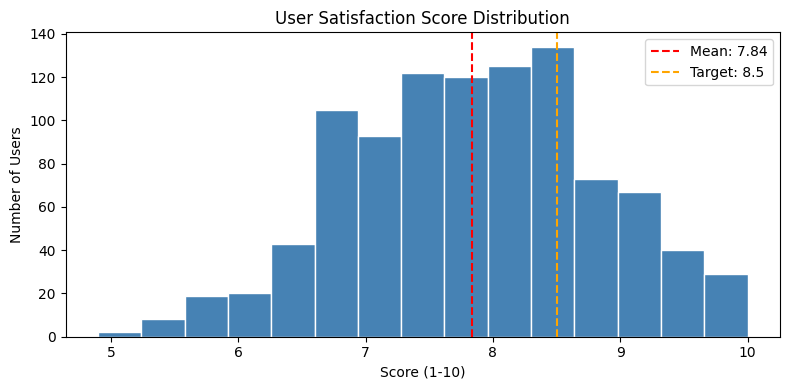

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(df['satisfaction_score'], bins=15, color='steelblue', edgecolor='white')
plt.axvline(df['satisfaction_score'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["satisfaction_score"].mean():.2f}')
plt.axvline(8.5, color='orange', linestyle='--', label='Target: 8.5')
plt.title('User Satisfaction Score Distribution')
plt.xlabel('Score (1-10)')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

### Graph — Renewal Probability Distribution

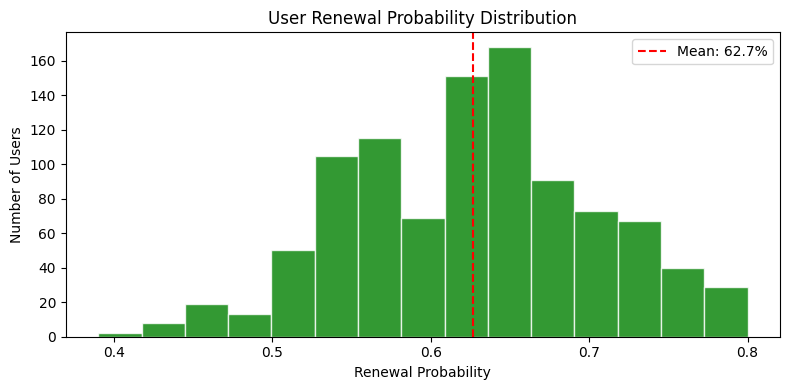

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(df['renewal_probability'], bins=15, color='green', edgecolor='white', alpha=0.8)
plt.axvline(df['renewal_probability'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["renewal_probability"].mean()*100:.1f}%')
plt.title('User Renewal Probability Distribution')
plt.xlabel('Renewal Probability')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

### Graph — Churn Risk Breakdown

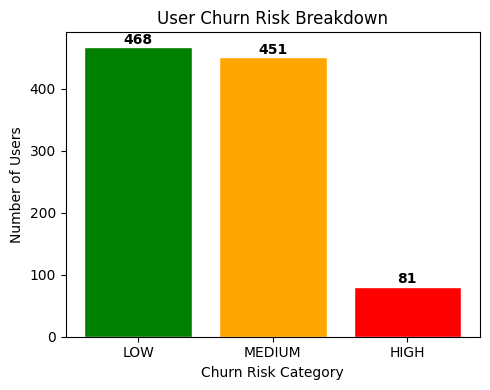

In [20]:
churn_counts = df['churn_risk'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])
colors = ['green', 'orange', 'red']
plt.figure(figsize=(5, 4))
plt.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white')
plt.title('User Churn Risk Breakdown')
plt.ylabel('Number of Users')
plt.xlabel('Churn Risk Category')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()